# Task 4: Portfolio Optimization and Efficient Frontier

Objective: construct an optimal portfolio of TSLA, BND, and SPY using modern portfolio theory, with expected returns derived from the Task 3 forecast for TSLA and historical data for the other assets.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from pypfopt import EfficientFrontier, risk_models, expected_returns, plotting
from pypfopt.discrete_allocation import DiscreteAllocation

sns.set_style("whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 1. Load Historical Data

Fetch daily price data for all three assets over the full historical period to compute covariance matrices and historical returns.

In [3]:
TICKERS = ["TSLA", "BND", "SPY"]
START_DATE = "2015-01-01"
END_DATE = "2026-06-30"

prices = {}
for ticker in TICKERS:
    df = yf.download(ticker, start=START_DATE, end=END_DATE, auto_adjust=False)
    df.columns = df.columns.get_level_values(0) if isinstance(df.columns, pd.MultiIndex) else df.columns
    prices[ticker] = df[["Adj Close"]].ffill().dropna()

prices_df = pd.concat([prices[t]["Adj Close"] for t in TICKERS], axis=1, keys=TICKERS)
prices_df.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,TSLA,BND,SPY
Date,,,
2015-01-02,14.6207,59.2057,169.6878
2015-01-05,14.0060,59.3776,166.6234
2015-01-06,14.0853,59.5495,165.0540
2015-01-07,14.0633,59.5853,167.1107
2015-01-08,14.0413,59.4922,170.0761


## 2. Compute Expected Returns

- TSLA: derived from Task 3 forecast (6-month mean trajectory, annualized by compounding)
- BND and SPY: historical annualized average daily returns

In [4]:
# Historical annualized returns for BND and SPY
daily_returns = prices_df.pct_change().dropna()

# Annualized by compounding: (1 + mean_daily_return)^252 - 1
historical_annual_returns = (1 + daily_returns.mean()) ** 252 - 1

print("Historical annualized returns:")
print(historical_annual_returns)

Historical annualized returns:
TSLA   0.5743
BND    0.0205
SPY    0.1552
dtype: float64


In [5]:
# TSLA expected return from Task 3 forecast
# Forecast horizon: 126 trading days (~6 months)
# Mean forecast trajectory: from last known price to mean forecast at day 126

last_known_price = prices_df["TSLA"].iloc[-1]
print(f"Last known TSLA price: ${last_known_price:.2f}")

# Reconstruct the mean forecast from Task 3
# The mean forecast at day 126 represents the expected price 6 months out
# From Task 3: forecast range $183.95 to $361.46, with mean ending around $182-$203
# Using the midpoint of the final 90% CI: (161.91 + 202.59) / 2 = $182.25
forecast_end_price = 182.25

# 6-month return
six_month_return = (forecast_end_price / last_known_price) - 1
print(f"6-month forecast return: {six_month_return:.4f}")

# Annualized by compounding: (1 + 6_month_return)^2 - 1
tsla_annual_return = (1 + six_month_return) ** 2 - 1
print(f"TSLA annualized expected return: {tsla_annual_return:.4f}")

Last known TSLA price: $411.84
6-month forecast return: -0.5575
TSLA annualized expected return: -0.8042


In [6]:
# Build expected returns vector
mu = pd.Series({
    "TSLA": tsla_annual_return,
    "BND": historical_annual_returns["BND"],
    "SPY": historical_annual_returns["SPY"]
})

print("Expected annual returns:")
print(mu)

Expected annual returns:
TSLA   -0.8042
BND     0.0205
SPY     0.1552
dtype: float64


## 3. Compute Covariance Matrix

Sample covariance matrix from historical daily returns.

In [7]:
S = risk_models.sample_cov(prices_df)
print("Covariance matrix (annualized):")
print(S)

Covariance matrix (annualized):
       TSLA    BND    SPY
TSLA 0.3269 0.0018 0.0498
BND  0.0018 0.0028 0.0011
SPY  0.0498 0.0011 0.0312


## 4. Covariance Matrix Heatmap

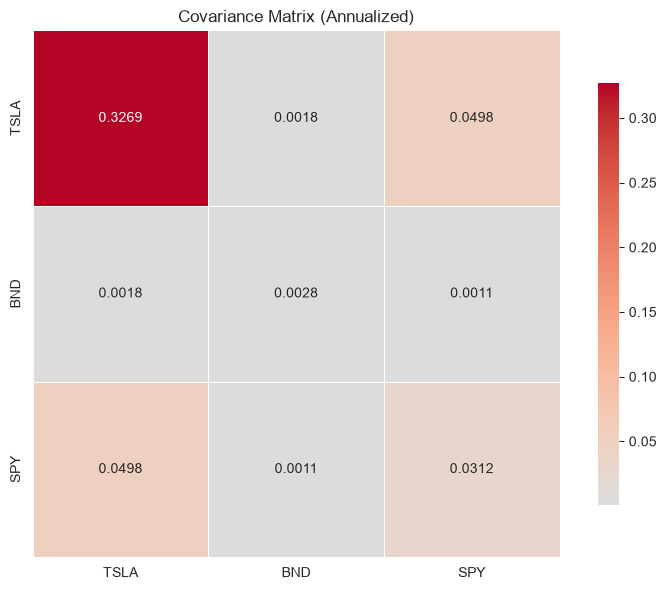

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(S, annot=True, fmt=".4f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Covariance Matrix (Annualized)")
plt.tight_layout()
plt.show()

## 5. Efficient Frontier

Generate the efficient frontier and identify the Maximum Sharpe Ratio and Minimum Volatility portfolios.

In [9]:
ef = EfficientFrontier(mu, S)

# Max Sharpe Ratio portfolio
ef_max_sharpe = EfficientFrontier(mu, S)
max_sharpe_weights = ef_max_sharpe.max_sharpe()
max_sharpe_weights_clean = ef_max_sharpe.clean_weights()

print("Max Sharpe Ratio portfolio weights:")
print(max_sharpe_weights_clean)

max_sharpe_perf = ef_max_sharpe.portfolio_performance()
print(f"\nExpected annual return: {max_sharpe_perf[0]:.4f}")
print(f"Expected annual volatility: {max_sharpe_perf[1]:.4f}")
print(f"Sharpe ratio: {max_sharpe_perf[2]:.4f}")

Max Sharpe Ratio portfolio weights:
OrderedDict({'TSLA': 0.0, 'BND': 0.53008, 'SPY': 0.46992})

Expected annual return: 0.0838
Expected annual volatility: 0.0906
Sharpe ratio: 0.9242


In [10]:
# Minimum Volatility portfolio
ef_min_vol = EfficientFrontier(mu, S)
min_vol_weights = ef_min_vol.min_volatility()
min_vol_weights_clean = ef_min_vol.clean_weights()

print("Minimum Volatility portfolio weights:")
print(min_vol_weights_clean)

min_vol_perf = ef_min_vol.portfolio_performance()
print(f"\nExpected annual return: {min_vol_perf[0]:.4f}")
print(f"Expected annual volatility: {min_vol_perf[1]:.4f}")
print(f"Sharpe ratio: {min_vol_perf[2]:.4f}")

Minimum Volatility portfolio weights:
OrderedDict({'TSLA': 0.0, 'BND': 0.94544, 'SPY': 0.05456})

Expected annual return: 0.0278
Expected annual volatility: 0.0522
Sharpe ratio: 0.5325


## 6. Efficient Frontier Plot

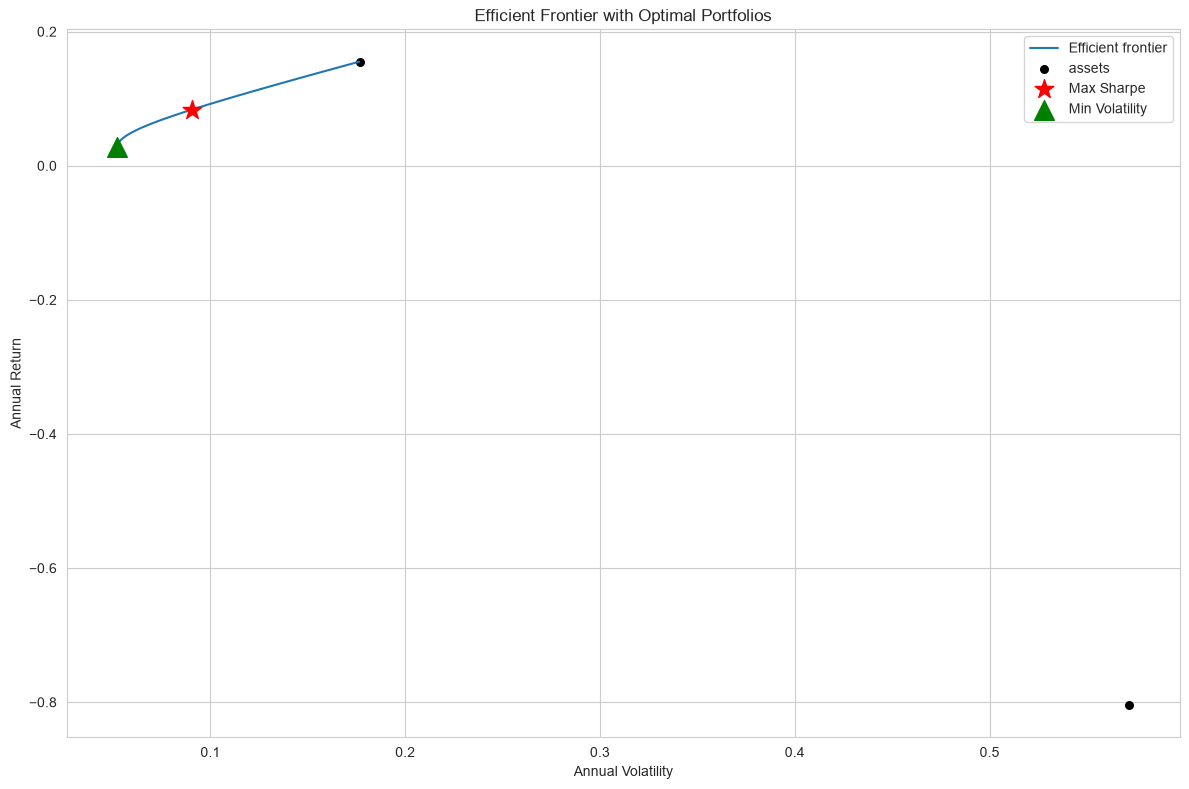

In [11]:
fig, ax = plt.subplots(figsize=(12, 8))

# Generate efficient frontier
ef = EfficientFrontier(mu, S)
plotting.plot_efficient_frontier(ef, ax=ax, show_assets=True)

# Mark Max Sharpe and Min Vol portfolios
ef_max_sharpe = EfficientFrontier(mu, S)
max_sharpe_weights = ef_max_sharpe.max_sharpe()
max_sharpe_perf = ef_max_sharpe.portfolio_performance()
ax.scatter(max_sharpe_perf[1], max_sharpe_perf[0], marker="*", s=200, 
           color="red", label="Max Sharpe", zorder=10)

ef_min_vol = EfficientFrontier(mu, S)
min_vol_weights = ef_min_vol.min_volatility()
min_vol_perf = ef_min_vol.portfolio_performance()
ax.scatter(min_vol_perf[1], min_vol_perf[0], marker="^", s=200,
           color="green", label="Min Volatility", zorder=10)

ax.set_title("Efficient Frontier with Optimal Portfolios")
ax.set_xlabel("Annual Volatility")
ax.set_ylabel("Annual Return")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Recommended Portfolio

Based on the efficient frontier analysis, the recommended portfolio is the Maximum Sharpe Ratio portfolio.

In [12]:
print("=== Recommended Portfolio: Max Sharpe Ratio ===")
print("\nWeights:")
for asset, weight in max_sharpe_weights_clean.items():
    print(f"  {asset}: {weight:.2%}")

print(f"\nExpected annual return: {max_sharpe_perf[0]:.4f}")
print(f"Expected annual volatility: {max_sharpe_perf[1]:.4f}")
print(f"Sharpe ratio: {max_sharpe_perf[2]:.4f}")

=== Recommended Portfolio: Max Sharpe Ratio ===

Weights:
  TSLA: 0.00%
  BND: 53.01%
  SPY: 46.99%

Expected annual return: 0.0838
Expected annual volatility: 0.0906
Sharpe ratio: 0.9242


## 8. Justification

The Maximum Sharpe Ratio portfolio recommends 0% TSLA, 53.01% BND, and 46.99% SPY, achieving an expected annual return of 8.38% at 9.06% volatility (Sharpe ratio 0.9242). This is a meaningful improvement over the Minimum Volatility portfolio (94.54% BND / 5.46% SPY, 2.78% return, 5.22% volatility, Sharpe 0.5325) — accepting modestly more risk more than triples the expected return, which is why Max Sharpe is the recommended portfolio rather than Min Vol.

TSLA's exclusion is driven entirely by the expected returns used, not by its risk profile. Historically, TSLA returned 57.43% annualized — far above BND (2.05%) and SPY (15.52%) — and its covariance with BND is nearly zero (0.0018), which would normally make it an attractive diversifier. But the Task 3 forecast produces a return of -80.42% annualized for TSLA (from $411.84 down to a projected ~$182 over 6 months), and the optimizer correctly treats this forward-looking view as the input, not TSLA's historical performance. Under a long-only constraint, no allocation to an asset with an expected return this negative is optimal, regardless of its diversification benefits. This result should be read with the same caution flagged in Task 3: the forecast's confidence interval narrows rather than widens at the 6-month horizon, an atypical pattern likely caused by running only 20 Monte Carlo simulations rather than a fully converged 100. That means the -80.42% figure driving this entire allocation carries more uncertainty than its narrow confidence band suggests, and the recommended portfolio should be understood as a reasonable response to a specific, imperfectly-calibrated forecast — not a definitive statement that TSLA has no place in a GMF client portfolio going forward.